# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу, який зберегли наприкінці попередньої роботи (з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки з метою виявлення звязку між ними, побудувавши їх візуалізації. Візуально оцініть наявність та силу зв'язку між ознаками.
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
4. Побудувати діаграму розмаху для 'CO2 emission' по регіонам.
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки з метою виявлення зв'язку між ними, побудувавши їх візуалізації</p>
</div>


Зчитую дані з файлу у датафрейм

In [19]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import pandas as pd
DATA_PATH = 'clean_data.csv'
df = pd.read_csv(DATA_PATH, sep=',', index_col=0)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470,164.427660


Будую діаграми

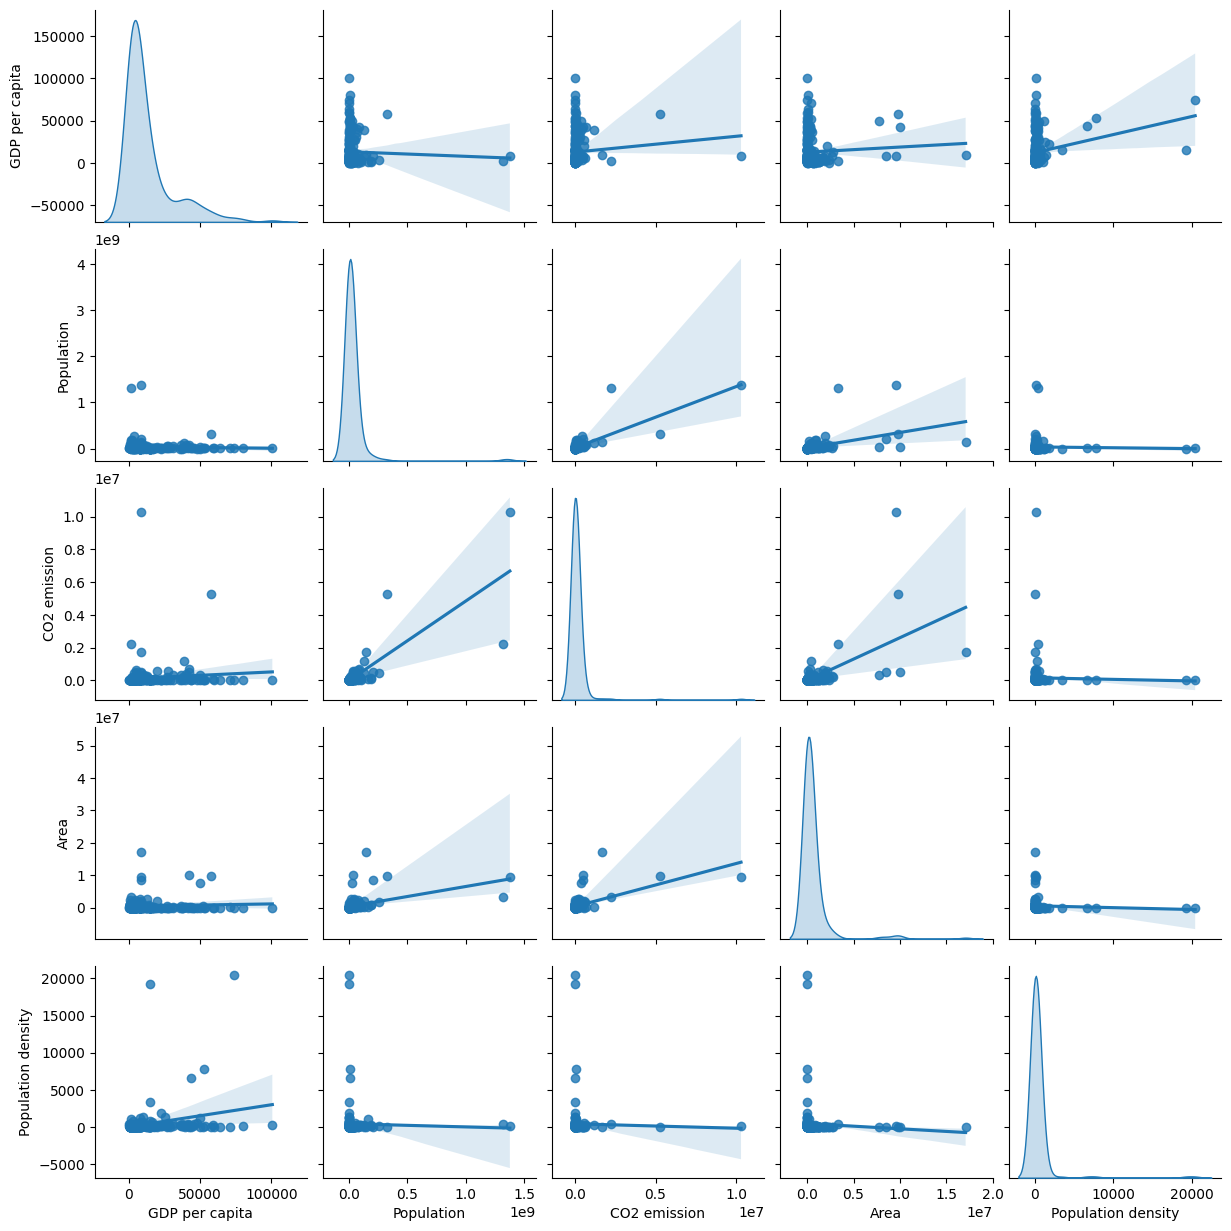

In [20]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import seaborn as sns
sns.pairplot(df, diag_kind='kde', kind='reg')

Візуально оцінінюю наявність та силу зв'язку між  ознаками.

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

<Axes: >

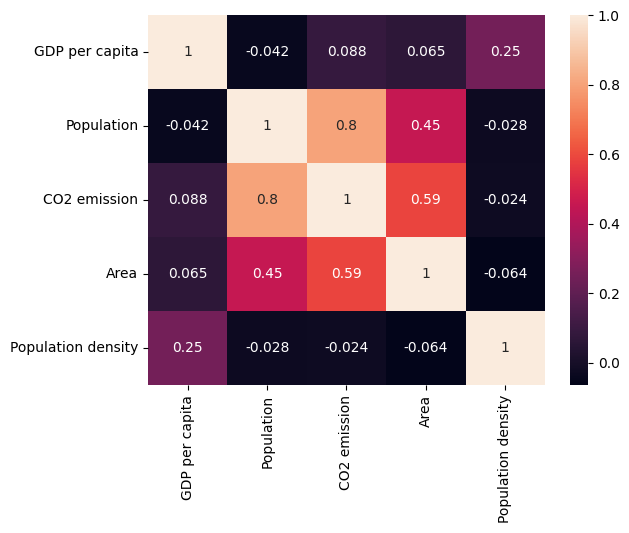

In [21]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True)

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Візуально оцінити наявність та силу зв'язку між цими ознаками.</p>
</div>


Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

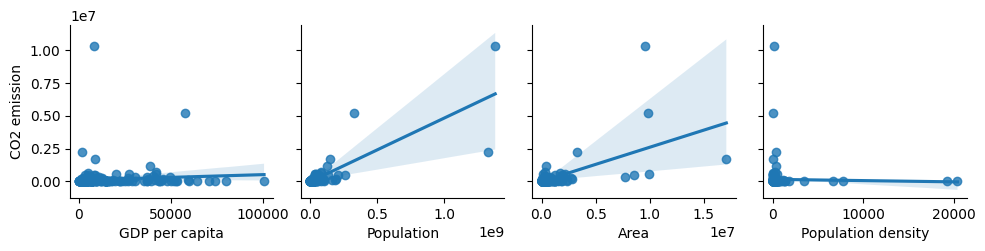

In [22]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.pairplot(numeric_df, x_vars=numeric_df.drop(columns=['CO2 emission']), y_vars=['CO2 emission'], kind='reg')

<p>Які кількісні ознаки можуть бути предикторами кількості викидів СО2? </p> <p> Обчислюю коефіцієнт кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'</p>

In [23]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from scipy import stats
for col in numeric_df.columns:
    if col == 'CO2 emission':
        continue
    r, p = stats.pearsonr(numeric_df[col], numeric_df['CO2 emission'])
    print(f"{col:<25}   PearsonR = {r:+.5f}   P value = {p:.5g}")

GDP per capita              PearsonR = +0.08843   P value = 0.19442
Population                  PearsonR = +0.80410   P value = 1.862e-50
Area                        PearsonR = +0.58830   P value = 1.3467e-21
Population density          PearsonR = -0.02390   P value = 0.72629


Виходячи з результатів маємо:

Population — r = +0.80, p ≈ 0 → сильний зв'язок, статистично значимий. Чим більше населення, тим більше викидів CO2. Найкращий предиктор.

Area — r = +0.59, p ≈ 0 → помірний зв'язок, статистично значимий. Більші за площею країни викидають більше CO2.

GDP per capita — r = +0.09, p = 0.19 → зв'язок слабкий і незначимий (p > 0.05). Не можна вважати предиктором.

Population density — r = -0.02, p = 0.73 → зв'язку практично немає, незначимий. Не предиктор.

Кількісні ознаки, які можуть бути предикторами кількості викидів СО2: Population та Area, оскільки вони мають статистично значиму кореляцію з CO2 emission (p < 0.05). 

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
</div>


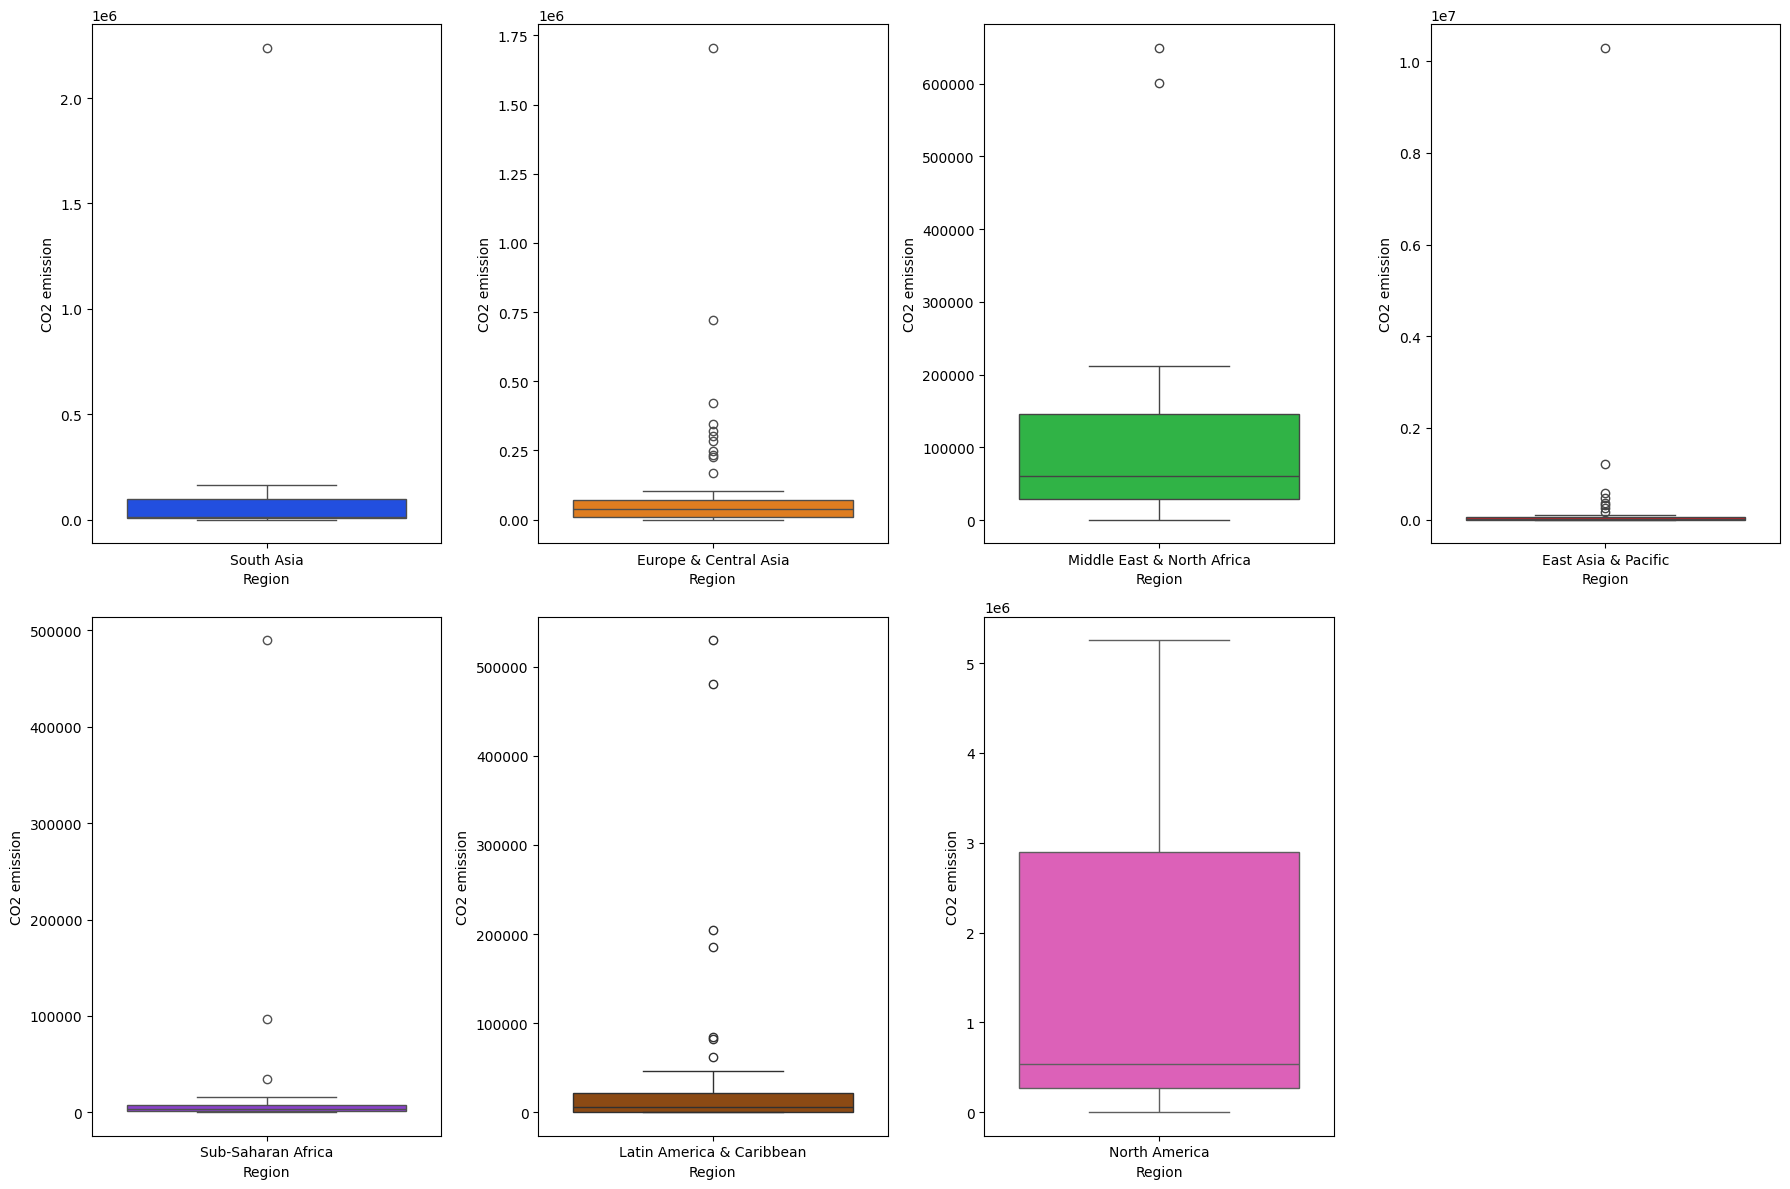

In [24]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import matplotlib.pyplot as plt
regions = df['Region'].unique()
colors = sns.color_palette("bright")
rows = (len(regions) + 3) // 4

fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(18, 6 * rows), tight_layout=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    sns.boxplot(data=df[df['Region'] == region], x='Region', y='CO2 emission', ax=axes[i], color=colors[i])

for j in range(len(regions), len(axes)):
    axes[j].axis('off')

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [25]:
groups = [group['CO2 emission'].values 
          for _, group in df.groupby('Region')]

Перевіряю розподіл даних в групах, щоб обрати вид дисперсійного аналізу.

In [ ]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

#Perform the Shapiro-Wilk test for normality.
#The Shapiro-Wilk test tests the null hypothesis that the data was drawn from a normal distribution.
for region, group in df.groupby('Region'):
    stat, p = stats.shapiro(group['CO2 emission'])
    normal = True if p > 0.05 else False
    print(f"{region:<35} p = {p:.5g}  ->  {'normal' if normal else 'not normal'}")

East Asia & Pacific                 p = 9.3025e-13  ->  not normal
Europe & Central Asia               p = 1.2528e-13  ->  not normal
Latin America & Caribbean           p = 1.8994e-11  ->  not normal
Middle East & North Africa          p = 5.5771e-06  ->  not normal
North America                       p = 0.17752  ->  normal
South Asia                          p = 4.8379e-06  ->  not normal
Sub-Saharan Africa                  p = 1.3857e-14  ->  not normal


Для отримання F-test score та P-value скористаюсь функцією <code>f_oneway</code> з модуля "stats" , якщо розподіл даних в групах дозволяє застосувати класичний дисперсійний аналіз, або <code>kruskal</code> з модуля "stats" для непараметричного дисперсійного аналізу Краскела-Уоліса.

In [27]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
if normal:
    stat, p = stats.f_oneway(*groups)
    test_name = 'F'
else:
    stat, p = stats.kruskal(*groups)
    test_name = 'H'

print(f"{test_name}-statistic = {stat:.5f},  p-value = {p:.5g}")


H-statistic = 44.68739,  p-value = 5.3996e-08


Результат із <code>H = 44.68739</code> показником тесту і <code>p-value = 5.3996e-08</code> показує, що між регіонами є статистично значима різниця у викидах CO2. Але чи означає це, що досліджувані групи значуще відрізняються між собою?

Розглянемо їх окремо.

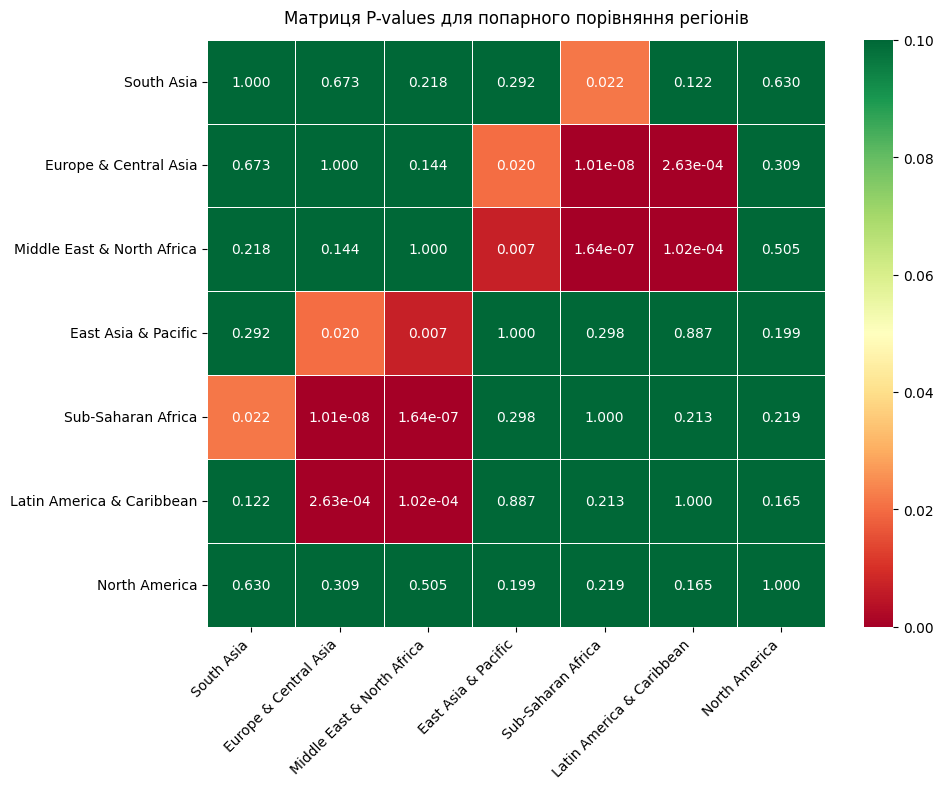

In [28]:
from itertools import combinations
import numpy as np

regions = df['Region'].unique()
n = len(regions)

# створюємо матрицю p-values
p_matrix = pd.DataFrame(np.ones((n, n)), index=regions, columns=regions)

for r1, r2 in combinations(regions, 2):
    g1 = df[df['Region'] == r1]['CO2 emission']
    g2 = df[df['Region'] == r2]['CO2 emission']
    _, p = stats.mannwhitneyu(g1, g2)
    p_matrix.loc[r1, r2] = p
    p_matrix.loc[r2, r1] = p

# форматуємо анотації
annot_matrix = p_matrix.map(lambda x: f'{x:.3f}' if x >= 0.001 else f'{x:.2e}')

# будуємо heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    p_matrix,
    annot=annot_matrix, fmt='',
    cmap='RdYlGn',
    vmin=0, vmax=0.1,
    linewidths=0.5, ax=ax
)
ax.set_title('Матриця P-values для попарного порівняння регіонів', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

<details><summary>Натисніть тут, щоб побачити підказку</summary>

Групування кількісної змінної в категорії було в попередній лабораторній роботі. Використайте функцію "cut"
</details>

In [29]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
min_p = 1.0
pair = ('', '')

for r1, r2 in combinations(regions, 2):
    p = p_matrix.loc[r1, r2]
    if p < min_p:
        min_p = p
        pair = (r1, r2)

print(f"Найбільша різниця між: {pair[0]} та {pair[1]}")
print(f"p-value = {min_p:.2e}")

Найбільша різниця між: Europe & Central Asia та Sub-Saharan Africa
p-value = 1.01e-08


Text(0, 0.5, 'CO2 emission')

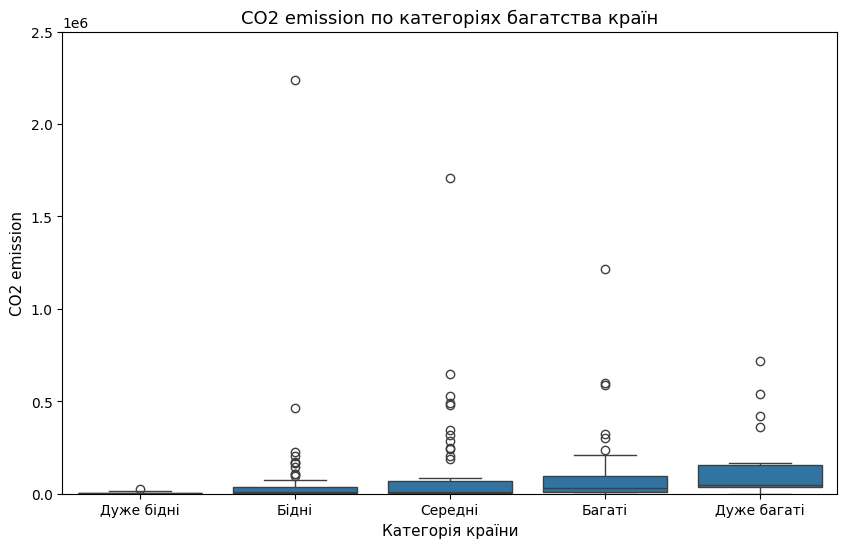

In [38]:
# створюємо категорії по GDP per capita
bins = [0, 1000, 5000, 15000, 40000, float('inf')]
labels = ['Дуже бідні', 'Бідні', 'Середні', 'Багаті', 'Дуже багаті']

df['Rich country'] = pd.cut(df['GDP per capita'], bins=bins, labels=labels)

# діаграма розмаху
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Дуже бідні', 'Бідні', 'Середні', 'Багаті', 'Дуже багаті']
sns.boxplot(data=df, x='Rich country', y='CO2 emission', 
            order=order, ax=ax)

plt.ylim(0, 25e5)

ax.set_title('CO2 emission по категоріях багатства країн', fontsize=13)
ax.set_xlabel('Категорія країни', fontsize=11)
ax.set_ylabel('CO2 emission', fontsize=11)

In [39]:
# групуємо
groups = [group['CO2 emission'].values 
          for _, group in df.groupby('Rich country')]

# перевірка нормальності
all_normal = True
for name, group in df.groupby('Rich country'):
    stat, p = stats.shapiro(group['CO2 emission'])
    is_normal = p > 0.05
    label = 'нормальний' if is_normal else 'НЕ нормальний'
    print(f"{name:<15} p = {p:.5g}  →  {label}")
    if not is_normal:
        all_normal = False

# обираємо тест
if all_normal:
    stat, p = stats.f_oneway(*groups)
    test_name = 'F'
else:
    stat, p = stats.kruskal(*groups)
    test_name = 'H'

print(f"\n{test_name}-statistic = {stat:.5f},  p-value = {p:.5g}\n")

# статистика по групах
summary = df.groupby('Rich country')['CO2 emission'].agg(
    Кількість='count',
    Середнє='mean',
    Медіана='median',
).round(2)
print(summary)

Дуже бідні      p = 1.0642e-05  →  НЕ нормальний
Бідні           p = 4.7499e-17  →  НЕ нормальний
Середні         p = 2.4729e-17  →  НЕ нормальний
Багаті          p = 3.503e-08  →  НЕ нормальний
Дуже багаті     p = 5.5413e-09  →  НЕ нормальний

H-statistic = 30.18490,  p-value = 4.488e-06

              Кількість    Середнє   Медіана
Rich country                                
Дуже бідні           31    4172.81   2449.56
Бідні                68   71418.65   9229.84
Середні              66  257117.54  10819.48
Багаті               30  135448.47  31008.15
Дуже багаті          22  368839.19  47463.81


<h2>Виконав студент групи ІП-44 <br> Комін Іван</h2>